In [ ]:
import pandas as pd

fake_df = pd.read_csv("Dataset/Fake.csv")
true_df = pd.read_csv("Dataset/True.csv")
indian_df = pd.read_csv("Dataset/news_dataset.csv")

print("Fake columns:", fake_df.columns)
print("True columns:", true_df.columns)
print("Indian columns:", indian_df.columns)

print(fake_df.shape)dc 
print(true_df.shape)
print(indian_df.shape)

Fake columns: Index(['title', 'text', 'subject', 'date'], dtype='object')
True columns: Index(['title', 'text', 'subject', 'date'], dtype='object')
Indian columns: Index(['label', 'text'], dtype='object')
(23481, 4)
(21417, 4)
(3729, 2)


***
Label create + text select


In [2]:
# Fake.csv → Fake News = 1
fake_df["label"] = 1

# True.csv → Real News = 0
true_df["label"] = 0

# title + text combine
fake_df["final_text"] = fake_df["title"].astype(str) + " " + fake_df["text"].astype(str)
true_df["final_text"] = true_df["title"].astype(str) + " " + true_df["text"].astype(str)

# Indian dataset already has text + label
indian_df["final_text"] = indian_df["text"].astype(str)

print(fake_df[["final_text", "label"]].head())
print(true_df[["final_text", "label"]].head())
print(indian_df[["final_text", "label"]].head())

                                          final_text  label
0   Donald Trump Sends Out Embarrassing New Year’...      1
1   Drunk Bragging Trump Staffer Started Russian ...      1
2   Sheriff David Clarke Becomes An Internet Joke...      1
3   Trump Is So Obsessed He Even Has Obama’s Name...      1
4   Pope Francis Just Called Out Donald Trump Dur...      1
                                          final_text  label
0  As U.S. budget fight looms, Republicans flip t...      0
1  U.S. military to accept transgender recruits o...      0
2  Senior U.S. Republican senator: 'Let Mr. Muell...      0
3  FBI Russia probe helped by Australian diplomat...      0
4  Trump wants Postal Service to charge 'much mor...      0
                                          final_text label
0  Payal has accused filmmaker Anurag Kashyap of ...  REAL
1  A four-minute-long video of a woman criticisin...  FAKE
2  Republic Poll, a fake Twitter account imitatin...  FAKE
3  Delhi teen finds place on UN green list, 

In [10]:
indian_df["label"].value_counts()

label
FAKE    1877
REAL    1852
Name: count, dtype: int64

In [11]:
indian_df["label"] = indian_df["label"].replace({
    "REAL": 0,
    "FAKE": 1
})

print(indian_df["label"].value_counts())

label
1    1877
0    1852
Name: count, dtype: int64


C:\Users\Asus\AppData\Local\Temp\ipykernel_9532\2348196087.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  indian_df["label"] = indian_df["label"].replace({


In [12]:
fake_final = fake_df[["final_text", "label"]]

true_final = true_df[["final_text", "label"]]

indian_final = indian_df[["final_text", "label"]]

print(fake_final.shape)
print(true_final.shape)
print(indian_final.shape)

(23481, 2)
(21417, 2)
(3729, 2)


***
Merge All Datasets

In [13]:
combined_df = pd.concat(
    [fake_final, true_final, indian_final],
    ignore_index=True
)

print("Combined Shape:", combined_df.shape)

combined_df.head()

Combined Shape: (48627, 2)


,final_text,label
0,Donald Trump Sends Out Embarrassing New Year’...,1
1,Drunk Bragging Trump Staffer Started Russian ...,1
2,Sheriff David Clarke Becomes An Internet Joke...,1
3,Trump Is So Obsessed He Even Has Obama’s Name...,1
4,Pope Francis Just Called Out Donald Trump Dur...,1


In [14]:
combined_df["label"].value_counts()

label
1    25358
0    23269
Name: count, dtype: int64

***
EDA process

In [15]:
print("Duplicates:", combined_df.duplicated().sum())

Duplicates: 7291


In [16]:
combined_df = combined_df.drop_duplicates()

print("After removing duplicates:", combined_df.shape)
print(combined_df["label"].value_counts())

After removing duplicates: (41336, 2)
label
0    21576
1    19760
Name: count, dtype: int64


In [17]:
combined_df = combined_df.rename(columns={"final_text": "text"})

combined_df.head()

,text,label
0,Donald Trump Sends Out Embarrassing New Year’...,1
1,Drunk Bragging Trump Staffer Started Russian ...,1
2,Sheriff David Clarke Becomes An Internet Joke...,1
3,Trump Is So Obsessed He Even Has Obama’s Name...,1
4,Pope Francis Just Called Out Donald Trump Dur...,1


In [18]:
import re

def clean_text(text):
    text = str(text)
    text = re.sub(r"http\S+|www\S+", "", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()

combined_df["clean_text"] = combined_df["text"].apply(clean_text)

combined_df[["clean_text", "label"]].head()

,clean_text,label
0,Donald Trump Sends Out Embarrassing New Year’s...,1
1,Drunk Bragging Trump Staffer Started Russian C...,1
2,Sheriff David Clarke Becomes An Internet Joke ...,1
3,Trump Is So Obsessed He Even Has Obama’s Name ...,1
4,Pope Francis Just Called Out Donald Trump Duri...,1


***
Train-Test Split

In [19]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    combined_df["clean_text"],
    combined_df["label"],
    test_size=0.2,
    random_state=42,
    stratify=combined_df["label"]
)

print("Train Size:", len(X_train))
print("Test Size:", len(X_test))

Train Size: 33068
Test Size: 8268


In [20]:
train_df = pd.DataFrame({
    "text": X_train,
    "label": y_train
})

test_df = pd.DataFrame({
    "text": X_test,
    "label": y_test
})

print(train_df.shape)
print(test_df.shape)

(33068, 2)
(8268, 2)


In [21]:
from datasets import Dataset

train_dataset = Dataset.from_pandas(train_df)
test_dataset = Dataset.from_pandas(test_df)

train_dataset

Dataset({
    features: ['text', 'label', '__index_level_0__'],
    num_rows: 33068
})

In [ ]:
train_dataset = train_dataset.remove_columns(["__index_level_0__"])
test_dataset = test_dataset.remove_columns(["__index_level_0__"])

print(train_dataset)
print(test_dataset)

Dataset({
    features: ['text', 'label'],
    num_rows: 33068
})
Dataset({
    features: ['text', 'label'],
    num_rows: 8268
})


***
Load Tokenizer

In [22]:
from transformers import AutoTokenizer

model_name = "distilbert-base-uncased"

tokenizer = AutoTokenizer.from_pretrained(model_name)

print("Tokenizer loaded")

Tokenizer loaded


In [23]:
def tokenize_function(batch):
    return tokenizer(
        batch["text"],
        padding="max_length",
        truncation=True,
        max_length=128
    )

In [ ]:
train_tokenized = train_dataset.map(tokenize_function, batched=True)
test_tokenized = test_dataset.map(tokenize_function, batched=True)

Map: 100%|██████████| 8268/8268 [00:03<00:00, 2085.39 examples/s]


***
Rename Label

In [ ]:
train_tokenized = train_tokenized.rename_column(
    "label",
    "labels"
)                                    

test_tokenized = test_tokenized.rename_column(
    "label",
    "labels"
)

In [ ]:
train_tokenized.set_format(
    type="torch",
    columns=["input_ids", "attention_mask", "labels"]
)

test_tokenized.set_format(
    type="torch",
    columns=["input_ids", "attention_mask", "labels"]
)

***
Load DistilBERT

In [ ]:
from transformers import AutoModelForSequenceClassification

model = AutoModelForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=2
)

print("Model Loaded")

Loading weights: 100%|██████████| 100/100 [00:00<00:00, 2449.86it/s]
[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model Loaded


***
Metrics Function

In [ ]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

def compute_metrics(pred):

    labels = pred.label_ids
    predictions = pred.predictions.argmax(-1)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels,
        predictions,
        average="binary"
    )

    accuracy = accuracy_score(labels, predictions)

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }

***
Training Arguments (V2)

In [ ]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="./results_v2",
    eval_strategy="epoch",
    save_strategy="epoch",

    learning_rate=2e-5,

    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,

    num_train_epochs=2,

    weight_decay=0.01,
    logging_steps=200,

    load_best_model_at_end=True,
    report_to="none"
)

In [ ]:
from transformers import Trainer

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_tokenized,
    eval_dataset=test_tokenized,
    compute_metrics=compute_metrics
)

print("Trainer ready")

Trainer ready


In [ ]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.006160,0.008715,0.998791,0.997979,0.999494,0.998736
2,0.006759,0.008320,0.999032,0.998231,0.999747,0.998989


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  2.23it/s]


TrainOutput(global_step=8268, training_loss=0.009033642157253975, metrics={'train_runtime': 1271.0678, 'train_samples_per_second': 52.032, 'train_steps_per_second': 6.505, 'total_flos': 2190215969378304.0, 'train_loss': 0.009033642157253975, 'epoch': 2.0})

In [ ]:
import torch

print(torch.__version__)
print(torch.cuda.is_available())

if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))

2.5.1+cu121
True
NVIDIA GeForce RTX 3050 A Laptop GPU


***
evaluate and  report


In [ ]:
eval_results = trainer.evaluate()
print(eval_results)

Training Loss,Validation Loss,Epoch,Accuracy,Precision,Recall,F1
0.006759,0.008320,2,0.999032,0.998231,0.999747,0.998989


{'eval_loss': 0.008319659158587456, 'eval_accuracy': 0.9990324141267537, 'eval_precision': 0.9982314300151591, 'eval_recall': 0.999746963562753, 'eval_f1': 0.9989886219974715}


In [ ]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

predictions = trainer.predict(test_tokenized)

y_pred = np.argmax(predictions.predictions, axis=1)
y_true = predictions.label_ids

print(classification_report(y_true, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      4316
           1       1.00      1.00      1.00      3952

    accuracy                           1.00      8268
   macro avg       1.00      1.00      1.00      8268
weighted avg       1.00      1.00      1.00      8268



***
Confusion matrix

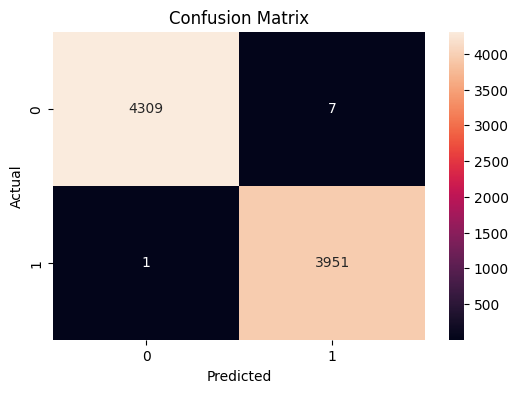

In [ ]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

***
Save Model

In [24]:
model.save_pretrained("distilbert_v2_indian_model")
tokenizer.save_pretrained("distilbert_v2_indian_model")

print("V2 Indian model saved successfully")

NameError: name 'model' is not defined

In [7]:
model_path = "distilbert_v2_indian_model"

In [4]:
def predict_news(text):
    ...

In [5]:
predict_news("""
The Indian Space Research Organisation (ISRO) successfully launched a new weather monitoring satellite...
""")